<a href="https://colab.research.google.com/github/jiveshsaini44/Unified-Practice/blob/main/Module_3_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3: Logistic Regression

In this assignment, you will
- explore the sigmoid function (also known as the logistic function)
- explore logistic regression; which uses the sigmoid function

In [16]:
import utils
print(utils.__file__)

/content/utils.py


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_data


## Sigmoid or Logistic Function
As discussed in the lecture videos, for a classification task, we can start by using our linear regression model, $h(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, to predict $y$ given $x$.
- However, we would like the predictions of our classification model to be between 0 and 1 since our output variable $y$ is either 0 or 1.
- This can be accomplished by using a "sigmoid function" which maps all input values to values between 0 and 1.


Let's implement the sigmoid function and see this for ourselves.

## Formula for Sigmoid function

The formula for a sigmoid function is as follows -  

$g(z) = \frac{1}{1+e^{-z}}\tag{1}$

In the case of logistic regression, z (the input to the sigmoid function), is the output of a linear regression model.
- In the case of a single example, $z$ is scalar.
- in the case of multiple examples, $z$ may be a vector consisting of $m$ values, one for each example.
- The implementation of the sigmoid function should cover both of these potential input formats.
Let's implement this in Python.

NumPy has a function called [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), which offers a convenient way to calculate the exponential ( $e^{z}$) of all elements in the input array (`z`).

It also works with a single number as an input, as shown below.

In [19]:
# Input is an array.
input_array = np.array([1,2,3])
exp_array = np.exp(input_array)

print("Input to exp:", input_array)
print("Output of exp:", exp_array)

# Input is a single number
input_val = 1
exp_val = np.exp(input_val)

print("Input to exp:", input_val)
print("Output of exp:", exp_val)

Input to exp: [1 2 3]
Output of exp: [ 2.71828183  7.3890561  20.08553692]
Input to exp: 1
Output of exp: 2.718281828459045


The `sigmoid` function is implemented in python as shown in the cell below.

In [25]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z

    """
    #####################################
    # WRITE THE SIGMOID FUNCTION HERE
    g =1/1+np.exp(z)

    #####################################

    return g


Let's see what the output of this function is for various value of `z`

In [26]:
# Generate an array of evenly spaced values between -10 and 10
z_tmp = np.arange(-10,11)

# Use the function implemented above to get the sigmoid values
y = sigmoid(z_tmp)

# Code for pretty printing the two arrays next to each other
np.set_printoptions(precision=3)
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  1.000e+00]
 [-9.000e+00  1.000e+00]
 [-8.000e+00  1.000e+00]
 [-7.000e+00  1.001e+00]
 [-6.000e+00  1.002e+00]
 [-5.000e+00  1.007e+00]
 [-4.000e+00  1.018e+00]
 [-3.000e+00  1.050e+00]
 [-2.000e+00  1.135e+00]
 [-1.000e+00  1.368e+00]
 [ 0.000e+00  2.000e+00]
 [ 1.000e+00  3.718e+00]
 [ 2.000e+00  8.389e+00]
 [ 3.000e+00  2.109e+01]
 [ 4.000e+00  5.560e+01]
 [ 5.000e+00  1.494e+02]
 [ 6.000e+00  4.044e+02]
 [ 7.000e+00  1.098e+03]
 [ 8.000e+00  2.982e+03]
 [ 9.000e+00  8.104e+03]
 [ 1.000e+01  2.203e+04]]


The values in the left column are `z`, and the values in the right column are `sigmoid(z)`. As you can see, the input values to the sigmoid range from -10 to 10, and the output values range from 0 to 1.

Now, let's try to plot this function using the `matplotlib` library.

Text(0.5, 0, 'z')

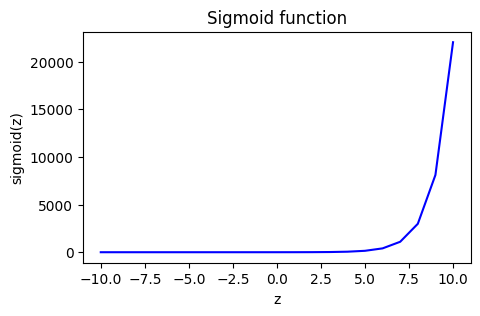

In [27]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')

As you can see, the sigmoid function approaches  `0` as `z` goes to large negative values and approaches `1` as `z` goes to large positive values.


## Decision Boundary
 Lets the decision boundary for a logistic regression model. This will give you a better sense of what the model is predicting.



Let's suppose you have following training dataset

*   The input variable X is a numpy array which has 6 training examples, each with two features
*   The output variable y is also a numpy array with 6 examples, and y is either 0 or 1

In [28]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1)

### Logistic regression model


* Suppose you'd like to train a logistic regression model on this data which has the form   

  $h(x) = g(w_0x_0+w_1x_1 + b)$
  
  where $g(z) = \frac{1}{1+e^{-z}}$, which is the sigmoid function


* Let's say that you trained the model and get the parameters as $b = -3, w_0 = 1, w_1 = 1$. That is,

  $h(x) = g(x_0+x_1-3)$

  (You'll learn how to train/fit and get these parameters in the further sections)
  
  
Let's try to understand what this trained model is predicting by plotting its decision boundary

* Recall that for logistic regression, the model is represented as

  $$h(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$

  where $g(z)$ is known as the sigmoid function and it maps all input values to values between 0 and 1:

  $g(z) = \frac{1}{1+e^{-z}}\tag{2}$
  and $\mathbf{w} \cdot \mathbf{x}$ is the vector dot product:
  
  $$\mathbf{w} \cdot \mathbf{x} = w_0 x_0 + w_1 x_1$$
  
  
 * We interpret the output of the model ($h(x)$) as the probability that $y=1$ given $\mathbf{x}$ and parameterized by $\mathbf{w}$ and $b$.
* Therefore, to get a final prediction ($y=0$ or $y=1$) from the logistic regression model, we can use the following heuristic -

  if $h(x) >= 0.5$, predict $y=1$
  
  if $h(x) < 0.5$, predict $y=0$
  
  
* Let's plot the sigmoid function to see where $g(z) >= 0.5$

## Plotting decision boundary

Now, let's go back to our example to understand how the logistic regression model is making predictions.

* Our logistic regression model has the form

  $h(\mathbf{x}) = g(-3 + x_0+x_1)$


* From what you've learnt above, you can see that this model predicts $y=1$ if $-3 + x_0+x_1 >= 0$

Let's see what this looks like graphically. We'll start by plotting $-3 + x_0+x_1 = 0$, which is equivalent to $x_1 = 3 - x_0$.

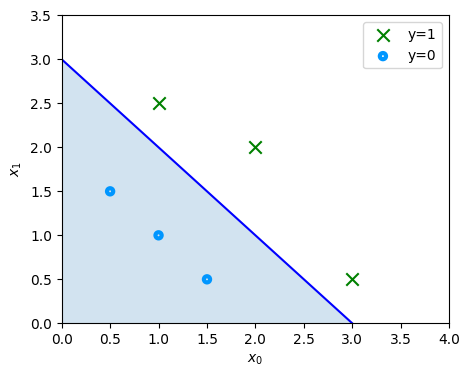

In [30]:
# Choose values between 0 and 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Plot the decision boundary
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0,x1, alpha=0.2)

# Plot the original data

plot_data(X,y,ax)
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

## Train a logistic regression model using scikit-learn

https://scikit-learn.org/0.16/modules/generated/sklearn.linear_model.LogisticRegression.html


- Create a Regression Object
- Call fit function
- Get predictions
- Get Score of model
- Get coefficients (w0, w1) and intercept(b)

In [32]:
from sklearn.linear_model import LogisticRegression



In [ ]:
###########################################################################
# YOUR CODE HERE

In [35]:
L_R=LogisticRegression()

In [36]:
L_R.fit(X,y)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [37]:
x_test=np.array([[0.5,1],[8,9],[5,6]])
y_pred=L_R.predict(x_test)
y_pred

array([0, 1, 1])

In [39]:
accuracy=L_R.score(X,y)
accuracy

1.0

In [44]:

intercept = L_R.intercept_[0]

coefficients = L_R.coef_[0]

print(f"Intercept (b): {intercept}")
print(f"Coefficient (w1): {coefficients[0]}")
print(f"Coefficient (w2): {coefficients[1]}")
print(coefficients)



Intercept (b): -2.3337163116769677
Coefficient (w1): 0.9041134943596743
Coefficient (w2): 0.7358754294504456
[0.904 0.736]
